# Modelo DINAMICO

"El modelo dinámico no predice clientes estáticos, predice TRANSICIONES. Cada compra es un evento temporal que cambia el estado del cliente. Agrupar por compra respeta la estructura causal de los datos: tras cada evento, predecimos qué pasa después. Esto es más realista, produce más observaciones de entrenamiento y simula exactamente lo que pasaría en un sistema realista.

- Predice el COMPORTAMIENTO, no la IDENTIDAD
- Estadísticamente: Más datos = Mejor modelo
- Predice el siguiente movimiento de un cliente, no su categoria global.

In [1]:
# %% =========================
# 1. CARGA Y LIMPIEZA
# =========================

import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix


df_unido = pd.read_csv("csv/online_retail_unificado.csv")
df = df_unido.copy()
df_sin_duplicados = df.drop_duplicates()
df = df_sin_duplicados.copy()

Registros limpios: 779425
Clientes únicos: 5878
Rango fechas: 2009-12-01 07:45:00 → 2011-12-09 12:50:00
Facturas únicas: 36969
Filas dataset supervisado: 30343

Distribución target:
target
1    22169
0     8174
Name: count, dtype: int64
target
1    0.730613
0    0.269387
Name: proportion, dtype: float64

Train: 21240
Test: 9103
Split date: 2011-02-14 09:31:48

ROC-AUC: 0.8347009471814112

Matriz de confusión:
[[1514  845]
 [1207 5537]]

Classification report:
              precision    recall  f1-score   support

           0       0.56      0.64      0.60      2359
           1       0.87      0.82      0.84      6744

    accuracy                           0.77      9103
   macro avg       0.71      0.73      0.72      9103
weighted avg       0.79      0.77      0.78      9103

Precision base: 0.741
Precision top 20%: 0.995
Lift: 1.34

Top 25 coeficientes por magnitud:
num__freq_90                         2.308839
cat__country_EIRE                    1.518649
num__frequency          

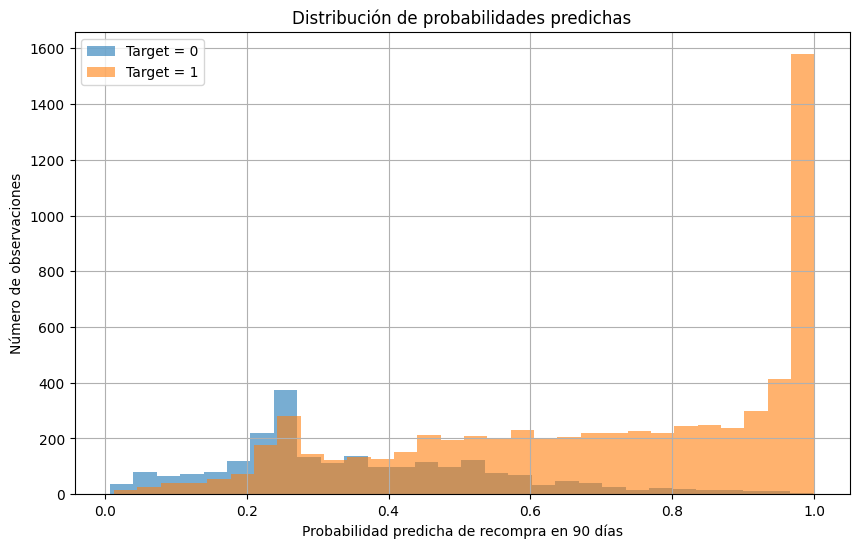


Tabla lift por decil:
   decile  n_obs  precision      lift
0       1    911   1.000000  1.349792
1       2    910   0.990110  1.336443
2       3    910   0.957143  1.291944
3       4    910   0.929670  1.254862
4       5    911   0.846323  1.142360
5       6    910   0.712088  0.961171
6       7    910   0.642857  0.867724
7       8    910   0.526374  0.710495
8       9    910   0.449451  0.606665
9      10    911   0.354555  0.478576


<function matplotlib.pyplot.show(close=None, block=None)>

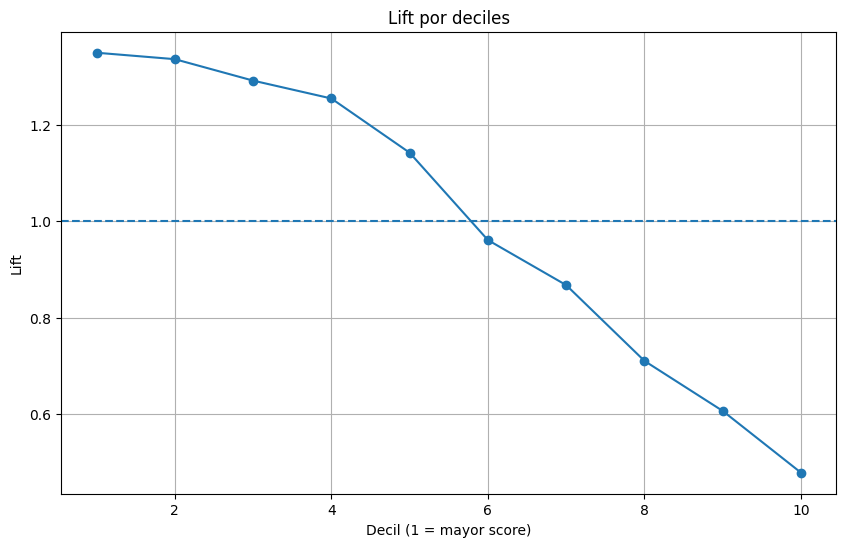

In [2]:
df_unido = pd.read_csv("../online_retail_unificado.csv")
df = df_unido.copy()
df_sin_duplicados = df.drop_duplicates()
df = df_sin_duplicados.copy()

# Fechas
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")

# Limpieza básica
df_clean = df[
    (df["Customer ID"].notnull()) &
    (df["Quantity"] > 0) &
    (df["Price"] > 0) &
    (df["InvoiceDate"].notnull())
].copy()

# Ingreso por línea
df_clean["total"] = df_clean["Quantity"] * df_clean["Price"]

print("Registros limpios:", len(df_clean))
print("Clientes únicos:", df_clean["Customer ID"].nunique())
print("Rango fechas:", df_clean["InvoiceDate"].min(), "→", df_clean["InvoiceDate"].max())


# %% =========================================
# 2) AGREGAR A NIVEL FACTURA
# =========================================
# Una fila por cliente-factura
df_inv = (
    df_clean.groupby(["Customer ID", "Invoice"], as_index=False)
    .agg(
        InvoiceDate=("InvoiceDate", "min"),
        total=("total", "sum"),
        Quantity=("Quantity", "sum"),
        Country=("Country", "first"),
        n_unique_products=("StockCode", "nunique"),
        n_lines=("StockCode", "size")
    )
)

df_inv = df_inv.sort_values(["Customer ID", "InvoiceDate"]).reset_index(drop=True)

print("Facturas únicas:", len(df_inv))


# %% =========================================
# 3) CONSTRUIR DATASET SUPERVISADO
#    TARGET:
#    ¿compra otra vez en <= 90 días desde esta compra?
# =========================================
HORIZON_DAYS = 90

max_date = df_inv["InvoiceDate"].max()
last_possible_anchor = max_date - pd.Timedelta(days=HORIZON_DAYS)

rows = []

for customer_id, g in df_inv.groupby("Customer ID", sort=False):
    g = g.sort_values("InvoiceDate").reset_index(drop=True)

    dates = g["InvoiceDate"].to_numpy(dtype="datetime64[ns]")
    totals = g["total"].to_numpy(float)
    qtys = g["Quantity"].to_numpy(float)
    nprod = g["n_unique_products"].to_numpy(float)
    n = len(g)

    # Acumulados para sacar features rápido
    ctot = np.cumsum(totals)
    cqty = np.cumsum(qtys)
    cprod = np.cumsum(nprod)

    # Solo usamos compras ancla con 90 días observables hacia delante
    valid_idx = np.where(pd.to_datetime(dates) <= last_possible_anchor)[0]

    if len(valid_idx) == 0:
        continue

    for i in valid_idx:
        anchor_date = pd.Timestamp(dates[i])

        # ---------- TARGET ----------
        # 1 si la siguiente compra llega en <= 90 días
        if i < n - 1:
            next_gap_days = (pd.Timestamp(dates[i + 1]) - anchor_date).days
            target = int(next_gap_days <= HORIZON_DAYS)
        else:
            target = 0

        # ---------- HISTORIAL HASTA ANCHOR ----------
        first_date = pd.Timestamp(dates[0])
        prev_date = pd.Timestamp(dates[i - 1]) if i >= 1 else first_date

        # Recency real: tiempo desde la compra previa hasta la compra ancla
        recency = (anchor_date - prev_date).days if i >= 1 else 0

        customer_age = (anchor_date - first_date).days
        frequency = i + 1
        monetary = ctot[i]
        avg_ticket = monetary / frequency
        cantidad_total = cqty[i]
        avg_products_per_invoice = cprod[i] / frequency

        # Tiempo medio y std entre compras
        if i >= 1:
            diffs = np.diff(pd.to_datetime(dates[:i + 1]).view("int64")) / (1e9 * 3600 * 24)
            avg_time_between = float(np.mean(diffs))
            std_time_between = float(np.std(diffs))
        else:
            avg_time_between = np.nan
            std_time_between = np.nan

        # ---------- VENTANAS RECIENTES ----------
        window_features = {}

        for w in [30, 60, 90, 180]:
            cutoff = np.datetime64(anchor_date - pd.Timedelta(days=w))

            # primera compra dentro de la ventana
            left = np.searchsorted(dates, cutoff, side="left")

            freq_w = i - left + 1
            spend_w = ctot[i] - (ctot[left - 1] if left > 0 else 0.0)
            qty_w = cqty[i] - (cqty[left - 1] if left > 0 else 0.0)

            window_features[f"freq_{w}"] = freq_w
            window_features[f"spend_{w}"] = spend_w
            window_features[f"qty_{w}"] = qty_w

        # Ratios recientes
        recent_ratio_30 = window_features["freq_30"] / frequency
        recent_ratio_90 = window_features["freq_90"] / frequency

        # Intensidades
        monetary_per_day = monetary / (customer_age + 1)
        freq_per_day = frequency / (customer_age + 1)

        rows.append({
            "Customer ID": customer_id,
            "anchor_date": anchor_date,
            "country": g.loc[i, "Country"],

            "recency": recency,
            "customer_age": customer_age,
            "frequency": frequency,
            "monetary": monetary,
            "avg_ticket": avg_ticket,
            "cantidad_total": cantidad_total,
            "avg_products_per_invoice": avg_products_per_invoice,
            "avg_time_between": avg_time_between,
            "std_time_between": std_time_between,

            "freq_30": window_features["freq_30"],
            "freq_60": window_features["freq_60"],
            "freq_90": window_features["freq_90"],
            "freq_180": window_features["freq_180"],

            "spend_30": window_features["spend_30"],
            "spend_60": window_features["spend_60"],
            "spend_90": window_features["spend_90"],
            "spend_180": window_features["spend_180"],

            "qty_30": window_features["qty_30"],
            "qty_60": window_features["qty_60"],
            "qty_90": window_features["qty_90"],
            "qty_180": window_features["qty_180"],

            "recent_ratio_30": recent_ratio_30,
            "recent_ratio_90": recent_ratio_90,
            "monetary_per_day": monetary_per_day,
            "freq_per_day": freq_per_day,

            "has_repeat_purchase": int(frequency > 1),
            "target": target
        })

df_features = pd.DataFrame(rows)

print("Filas dataset supervisado:", len(df_features))
print("\nDistribución target:")
print(df_features["target"].value_counts())
print(df_features["target"].value_counts(normalize=True))


# %% =========================================
# 4) PREPARACIÓN PARA MODELADO
# =========================================
# Variables numéricas y categóricas
num_features = [
    "recency",
    "customer_age",
    "frequency",
    "monetary",
    "avg_ticket",
    "cantidad_total",
    # "avg_products_per_invoice",
    "avg_time_between",
    "std_time_between",
    # "freq_30",
    # "freq_60",
    "freq_90",
    # "freq_180",
    # "spend_30",
    # "spend_60",
    "spend_90",
    # "spend_180",
    # "qty_30",
    # "qty_60",
    "qty_90",
    # "qty_180",
    # "recent_ratio_30",
    # "recent_ratio_90",
    # "monetary_per_day",
    "freq_per_day",
    "has_repeat_purchase"
]

# num_features = [
#     "recency",
#     "ultima_compra",
#     # "customer_age",
#     "cantidad_total",
#     "frequency",
#     "monetary",
#     "avg_ticket",
#     # "avg_products_per_invoice",
#     "avg_time_between",
#     "std_time_between",
#     # "freq_30",
#     # "freq_60",
#     "freq_90",
#     # "freq_180",
#     # "spend_30",
#     # "spend_60",
#     "spend_90",
#     # "spend_180",
#     # "qty_30",
#     # "qty_60",
#     "qty_90",
#     # "qty_180",
#     # "recent_ratio_30",
#     # "recent_ratio_90",
#     # "monetary_per_day",
#     # "freq_per_day",
#     "has_repeat_purchase"
# ]



cat_features = ["country"]

X = df_features[num_features + cat_features]
y = df_features["target"]

# Split temporal real: entrenas con anchors más antiguos y test con anchors más recientes
split_date = df_features["anchor_date"].quantile(0.7)

train_idx = df_features["anchor_date"] <= split_date
test_idx = df_features["anchor_date"] > split_date

X_train = X.loc[train_idx].copy()
X_test = X.loc[test_idx].copy()
y_train = y.loc[train_idx].copy()
y_test = y.loc[test_idx].copy()

print("\nTrain:", len(X_train))
print("Test:", len(X_test))
print("Split date:", split_date)


# %% =========================================
# 5) PIPELINE + MODELO
# =========================================
preprocess = ColumnTransformer([
    (
        "num",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]),
        num_features
    ),
    (
        "cat",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]),
        cat_features
    )
])

# Ojo: aquí la clave no es tanto el algoritmo como la reformulación del dataset
model = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

model.fit(X_train, y_train)



# %% =========================================
# 6) EVALUACIÓN
# =========================================
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba >= 0.4).astype(int)          # umbral bajo para priorizar recall (capturar más compradores futuros aunque haya falsos positivos)

auc = roc_auc_score(y_test, y_pred_proba)

print("\nROC-AUC:", auc)
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification report:")
print(classification_report(y_test, y_pred))


# %% =========================================
# 7) PRECISION BASE, TOP 20% Y LIFT
# =========================================
df_eval = pd.DataFrame({
    "y_true": y_test.values,
    "y_score": y_pred_proba
}).sort_values("y_score", ascending=False)

top_n = int(len(df_eval) * 0.2)

precision_base = df_eval["y_true"].mean()
precision_top20 = df_eval.iloc[:top_n]["y_true"].mean()
lift = precision_top20 / precision_base

print("Precision base:", round(precision_base, 3))
print("Precision top 20%:", round(precision_top20, 3))
print("Lift:", round(lift, 2))


# %% =========================================
# 8) IMPORTANCIA DE VARIABLES
# =========================================
# Para recuperar nombres tras one-hot
feature_names = model.named_steps["prep"].get_feature_names_out()
coefs = model.named_steps["clf"].coef_[0]

importance = (
    pd.Series(coefs, index=feature_names)
    .sort_values(key=np.abs, ascending=False)
)

print("\nTop 25 coeficientes por magnitud:")
print(importance.head(25))


# %% =========================================
# 9) HISTOGRAMA DE PROBABILIDADES
# =========================================
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(y_pred_proba[y_test == 0], bins=30, alpha=0.6, label="Target = 0")
plt.hist(y_pred_proba[y_test == 1], bins=30, alpha=0.6, label="Target = 1")
plt.xlabel("Probabilidad predicha de recompra en 90 días")
plt.ylabel("Número de observaciones")
plt.title("Distribución de probabilidades predichas")
plt.legend()
plt.grid(True)
plt.show()


# %% =========================================
# 10) CURVA DE LIFT POR DECILES
# =========================================
df_lift = df_eval.copy()
df_lift["decile"] = pd.qcut(
    df_lift["y_score"].rank(method="first", ascending=False),
    10,
    labels=False
) + 1

lift_table = (
    df_lift.groupby("decile")
    .agg(
        n_obs=("y_true", "size"),
        precision=("y_true", "mean")
    )
    .reset_index()
)

lift_table["lift"] = lift_table["precision"] / precision_base

print("\nTabla lift por decil:")
print(lift_table)

plt.figure(figsize=(10, 6))
plt.plot(lift_table["decile"], lift_table["lift"], marker="o")
plt.axhline(1.0, linestyle="--")
plt.xlabel("Decil (1 = mayor score)")
plt.ylabel("Lift")
plt.title("Lift por deciles")
plt.grid(True)
plt.show

## Graficos

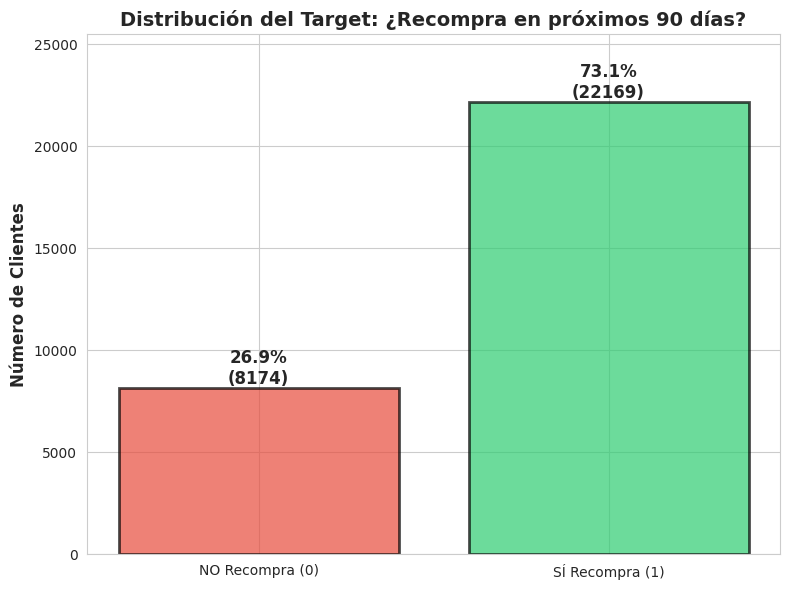


INSIGHT 1: DISTRIBUCIÓN DEL TARGET
Clientes que NO recompran (0): 8174 (26.9%)
Clientes que SÍ recompran (1): 22169 (73.1%)
Dataset DESBALANCEADO: usar class_weight='balanced' en el modelo


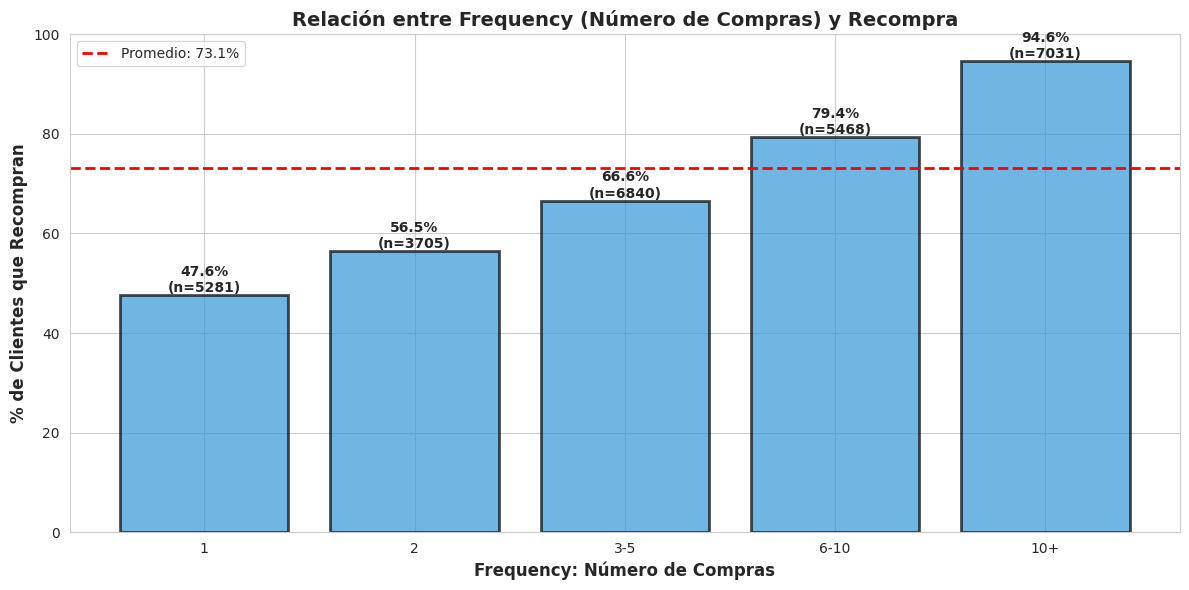


INSIGHT 2: FREQUENCY vs RECOMPRA
           sum  count  tasa_recompra
freq_bin                            
1         2513   5281           47.6
2         2093   3705           56.5
3-5       4554   6840           66.6
6-10      4340   5468           79.4
10+       6653   7031           94.6

Insight: Clientes con MÁS compras tienen MUCHA más probabilidad de recompra


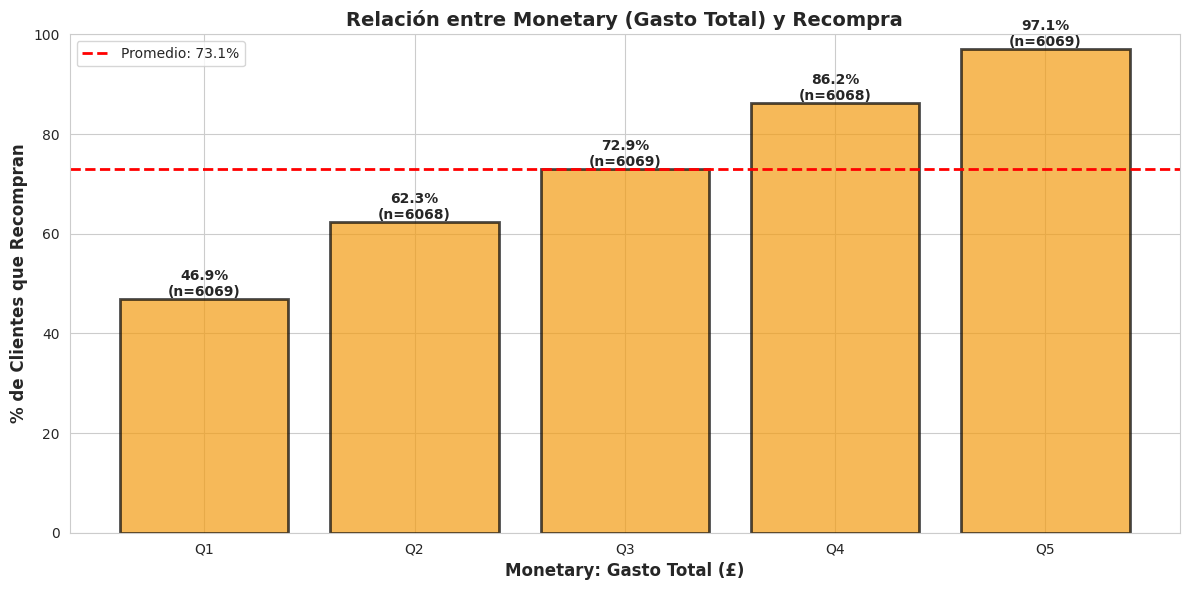


INSIGHT 3: MONETARY vs RECOMPRA
                                sum  count  tasa_recompra
monetary_bin                                             
(1.2990000000000002, 475.344]  2846   6069           46.9
(475.344, 1161.256]            3778   6068           62.3
(1161.256, 2572.624]           4425   6069           72.9
(2572.624, 6876.446]           5229   6068           86.2
(6876.446, 456780.49]          5891   6069           97.1


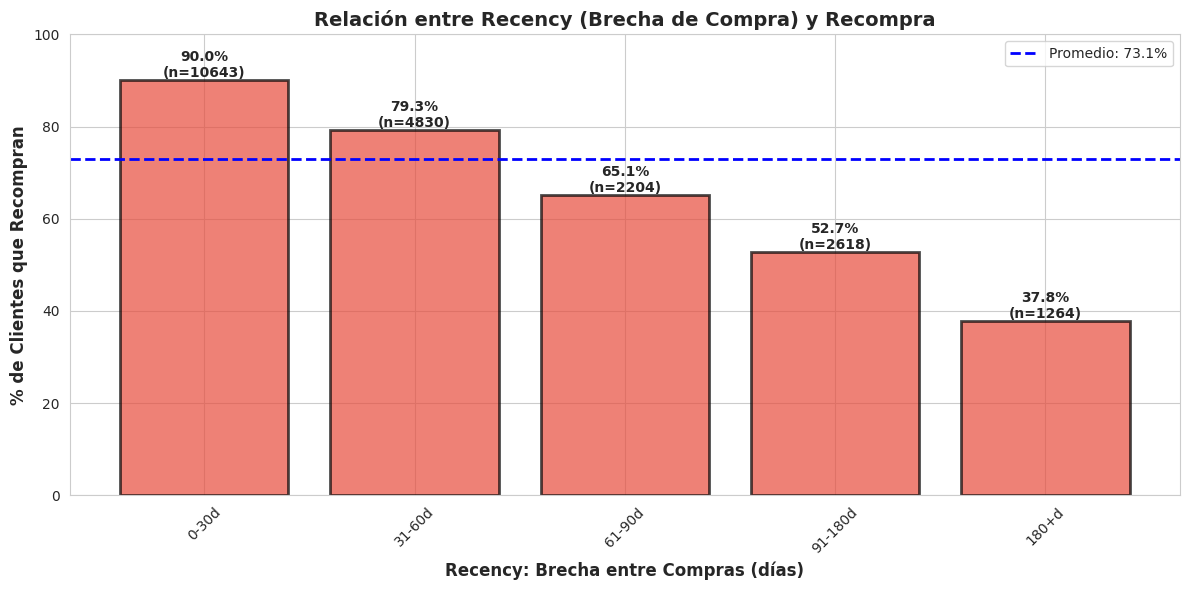


INSIGHT 4: RECENCY vs RECOMPRA
              sum  count  tasa_recompra
recency_bin                            
0-30d        9576  10643           90.0
31-60d       3832   4830           79.3
61-90d       1435   2204           65.1
91-180d      1379   2618           52.7
180+d         478   1264           37.8

Insight: RECENCY ALTO = MÁS riesgo de churn. Clientes con brechas grandes no recompran


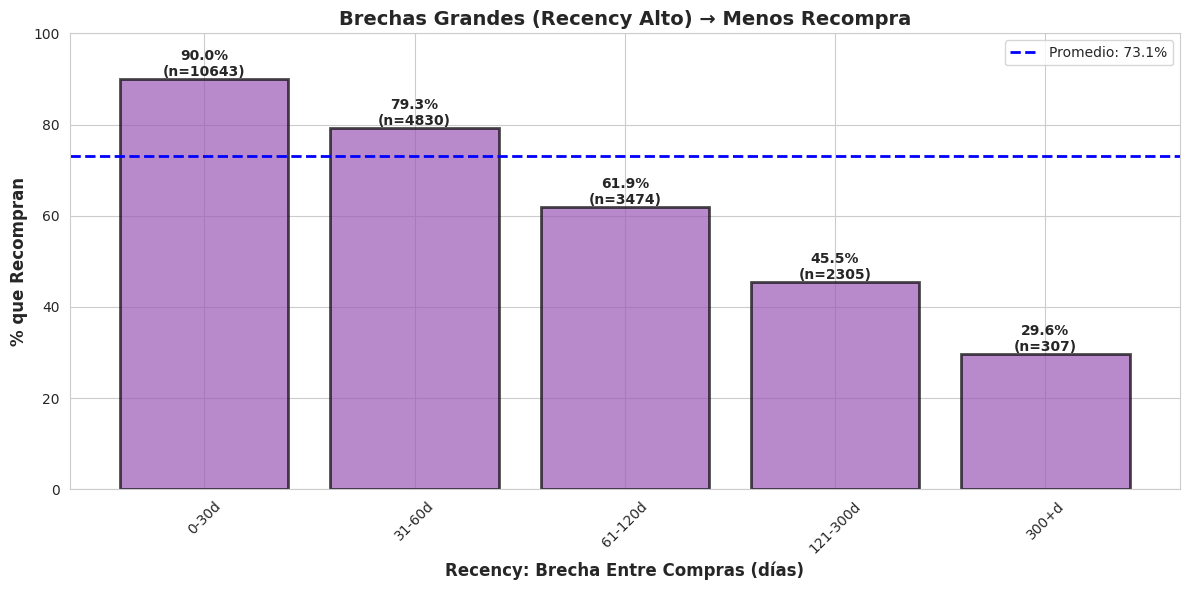


INSIGHT 5: RECENCY ALTO → MENOR RECOMPRA
                   sum  count  tasa_recompra
recency_bin_alto                            
0-30d             9576  10643           90.0
31-60d            3832   4830           79.3
61-120d           2152   3474           61.9
121-300d          1049   2305           45.5
300+d               91    307           29.6


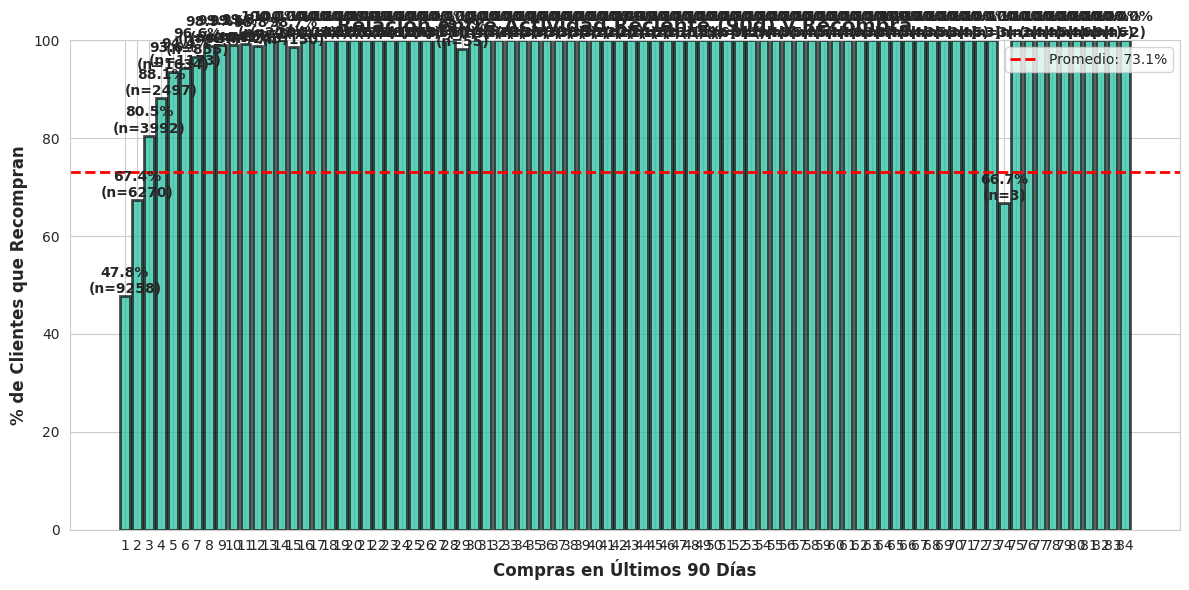


INSIGHT 6: ACTIVIDAD RECIENTE (freq_90) vs RECOMPRA
          sum  count  tasa_recompra
freq_90                            
1        4427   9258           47.8
2        4225   6270           67.4
3        3214   3992           80.5
4        2199   2497           88.1
5        1530   1634           93.6
...       ...    ...            ...
80          6      6          100.0
81          9      9          100.0
82          4      4          100.0
83          6      6          100.0
84          2      2          100.0

[84 rows x 3 columns]

Insight: Clientes activos en últimos 90d tienen MUCHA mayor probabilidad de recompra


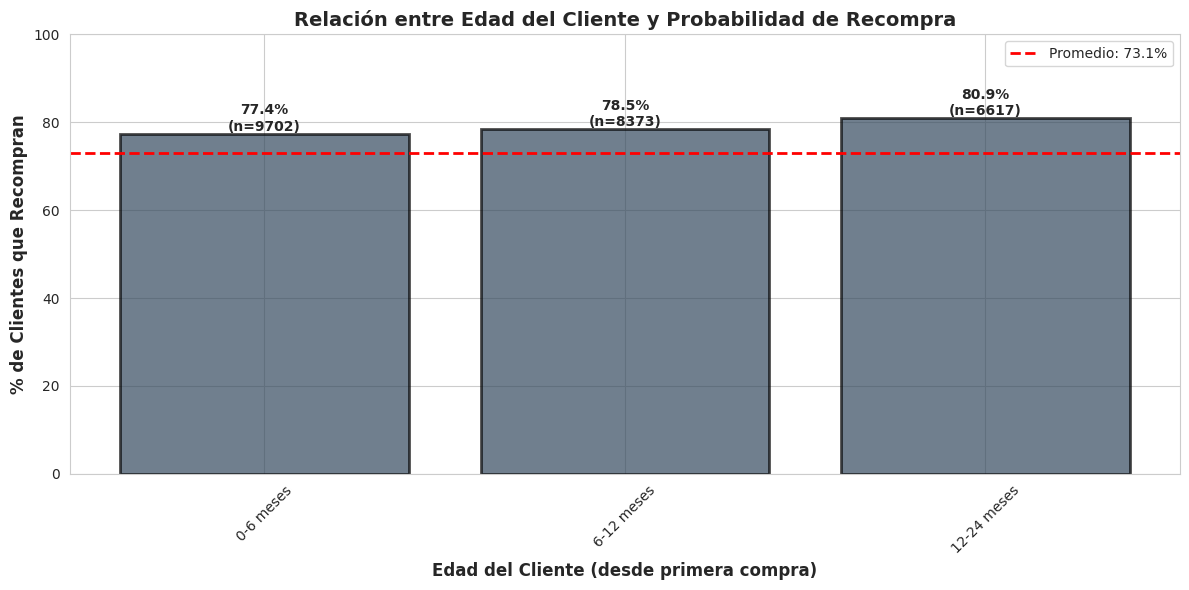


INSIGHT 7: CUSTOMER AGE vs RECOMPRA
              sum  count  tasa_recompra
age_bin                                
0-6 meses    7513   9702           77.4
6-12 meses   6576   8373           78.5
12-24 meses  5351   6617           80.9

Insight: Clientes nuevos (0-6 meses) tienen menor probabilidad de recompra


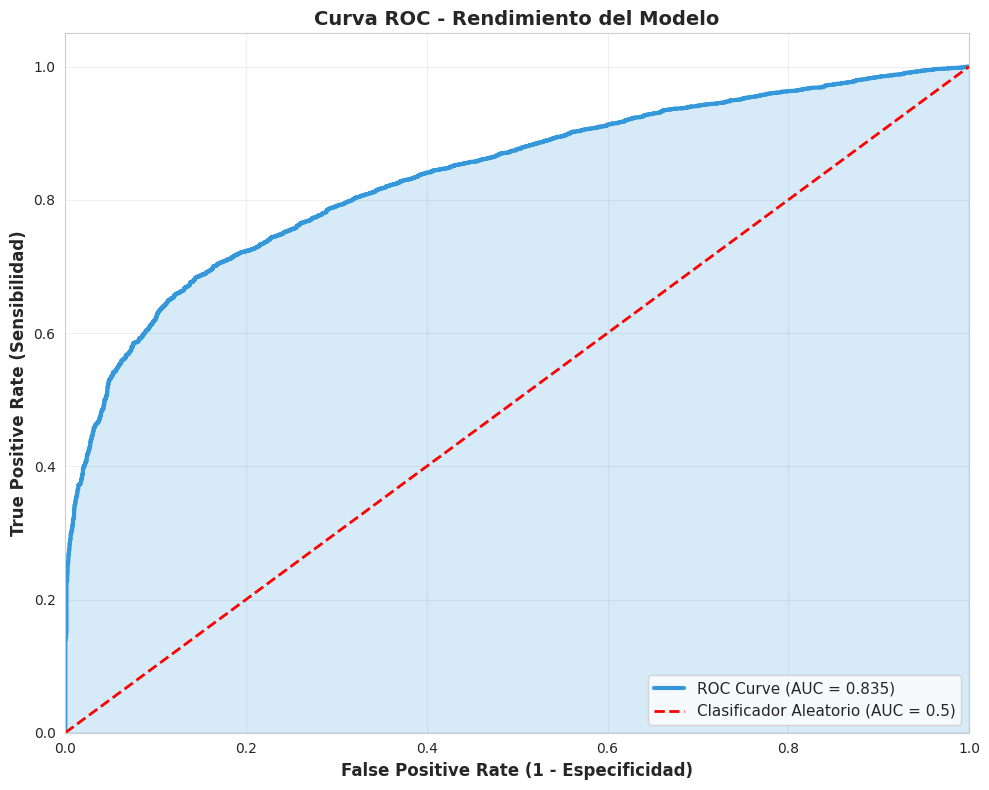


INSIGHT 8: CURVA ROC Y AUC
AUC-ROC: 0.8347
Interpretación: El modelo tiene un 83.5% de probabilidad de distinguir entre:
  - Un cliente que recompra
  - Un cliente que NO recompra

Valores AUC: 0.5=malo, 0.7=aceptable, 0.8=bueno, 0.9+=excelente
✓ AUC > 0.8: MODELO BUENO para usar en producción


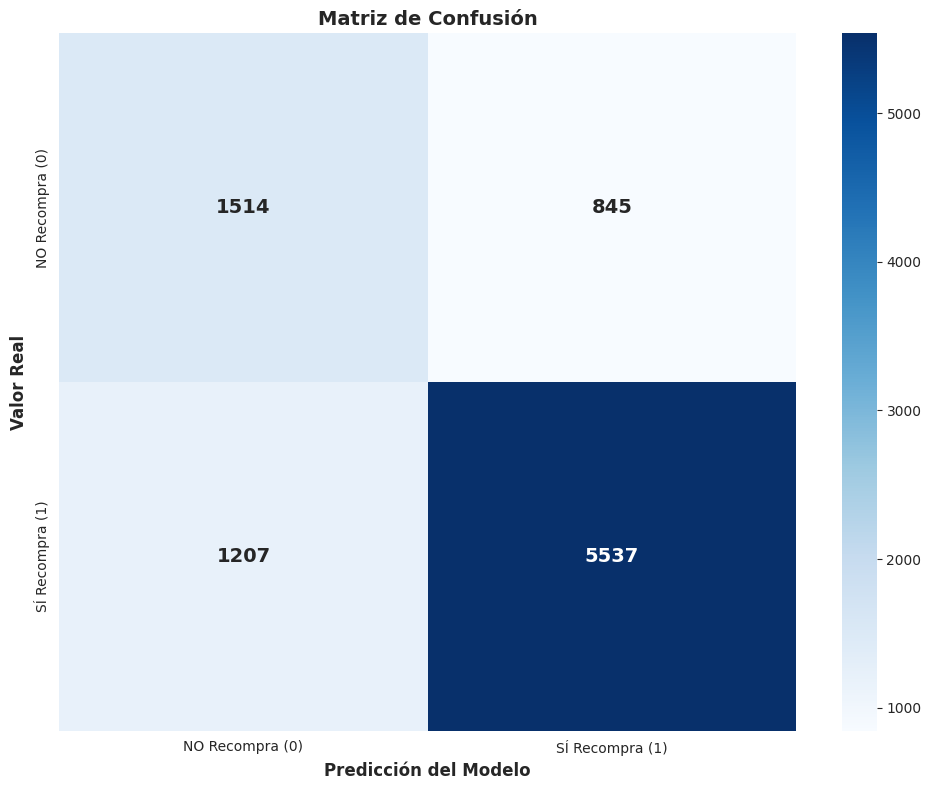


INSIGHT 9: MATRIZ DE CONFUSIÓN
Verdaderos Negativos (TN): 1514 (predijo NO, era NO) ✓
Falsos Positivos (FP): 845 (predijo SÍ, era NO) ✗
Falsos Negativos (FN): 1207 (predijo NO, era SÍ) ✗✗ PEOR
Verdaderos Positivos (TP): 5537 (predijo SÍ, era SÍ) ✓

Métricas:
  Sensibilidad (TPR): 0.821 (¿cuántos que recompran detectamos?)
  Especificidad (TNR): 0.642 (¿cuántos que NO recompran detectamos?)
  Precisión: 0.868 (¿de los que predimos que compran, cuántos realmente lo hacen?)


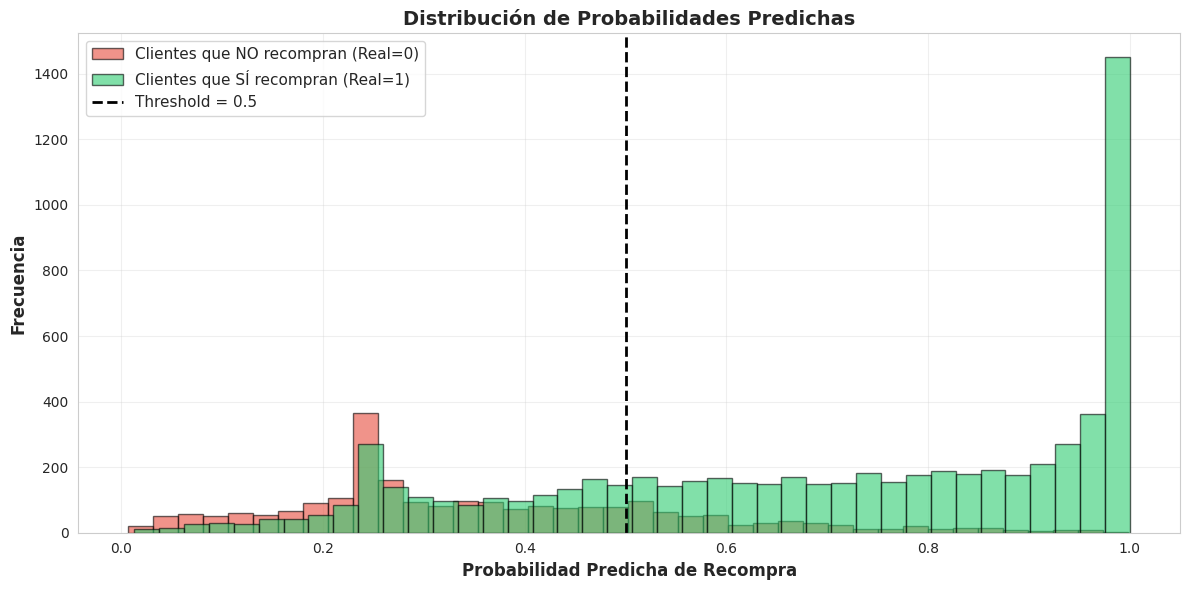


INSIGHT 10: DISTRIBUCIÓN DE PROBABILIDADES PREDICHAS
Probabilidad promedio para clientes que NO recompran: 0.355
Probabilidad promedio para clientes que SÍ recompran: 0.698

Insight: Hay buena separación entre las dos distribuciones → modelo diferencia bien


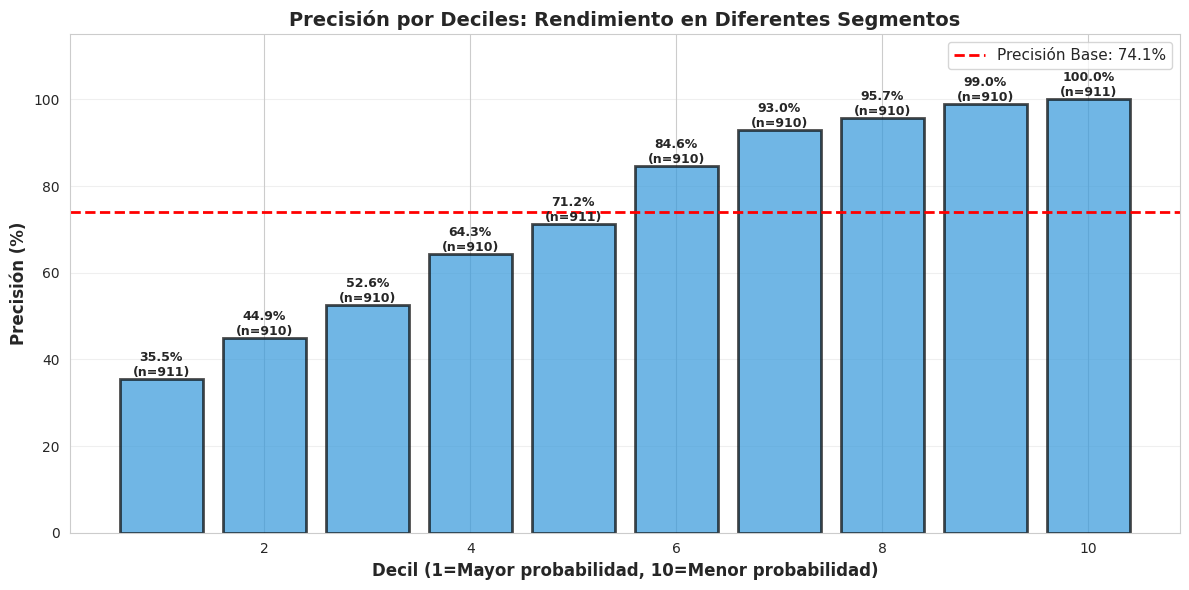


INSIGHT 11: PRECISIÓN POR DECILES
   decile  recompras  total_clientes   precision      lift
0       1        323             911   35.455543  0.478576
1       2        409             910   44.945055  0.606665
2       3        479             910   52.637363  0.710495
3       4        585             910   64.285714  0.867724
4       5        649             911   71.240395  0.961597
5       6        770             910   84.615385  1.142132
6       7        846             910   92.967033  1.254862
7       8        871             910   95.714286  1.291944
8       9        901             910   99.010989  1.336443
9      10        911             911  100.000000  1.349792

Insight: Si enfocas acciones en Decil 1 (top 10%), aciertas 35.5%
Lift en Decil 1: 0.48x (modelo es 0.48x mejor que random)

TODAS LAS GRÁFICAS GENERADAS
✓ 01_distribucion_target.png
✓ 02_frequency_vs_recompra.png
✓ 03_monetary_vs_recompra.png
✓ 04_recency_vs_recompra.png
✓ 05_inactividad_vs_recompra.png
✓ 06_freq

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report

# Configurar estilo
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

# ============================================================================
# ASUME QUE TIENES: df_static, y_test, y_pred_proba
# ============================================================================

# %% =========================================
# GRÁFICA 1: DISTRIBUCIÓN DEL TARGET
# =========================================
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

target_counts = df_features['target'].value_counts()
colors = ['#e74c3c', '#2ecc71']
labels = ['NO Recompra (0)', 'SÍ Recompra (1)']

bars = ax.bar(labels, [target_counts[0], target_counts[1]], color=colors, alpha=0.7, edgecolor='black', linewidth=2)

# Añadir porcentajes
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height/len(df_features)*100:.1f}%\n({int(height)})',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Número de Clientes', fontsize=12, fontweight='bold')
ax.set_title('Distribución del Target: ¿Recompra en próximos 90 días?', fontsize=14, fontweight='bold')
ax.set_ylim([0, max(target_counts) * 1.15])

plt.tight_layout()
plt.savefig('01_distribucion_target.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n{'='*70}")
print("INSIGHT 1: DISTRIBUCIÓN DEL TARGET")
print(f"{'='*70}")
print(f"Clientes que NO recompran (0): {target_counts[0]} ({target_counts[0]/len(df_features)*100:.1f}%)")
print(f"Clientes que SÍ recompran (1): {target_counts[1]} ({target_counts[1]/len(df_features)*100:.1f}%)")
print(f"Dataset DESBALANCEADO: usar class_weight='balanced' en el modelo")

# %% =========================================
# GRÁFICA 2: FREQUENCY vs RECOMPRA
# =========================================
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# Crear bins de frequency
df_features['freq_bin'] = pd.cut(df_features['frequency'], bins=[0, 1, 2, 5, 10, 50], 
                                labels=['1', '2', '3-5', '6-10', '10+'])

recompra_by_freq = df_features.groupby('freq_bin')['target'].agg(['sum', 'count'])
recompra_by_freq['tasa_recompra'] = (recompra_by_freq['sum'] / recompra_by_freq['count'] * 100).round(1)

x = range(len(recompra_by_freq))
bars = ax.bar(x, recompra_by_freq['tasa_recompra'], color='#3498db', alpha=0.7, edgecolor='black', linewidth=2)

# Añadir percentajes y conteos
for i, (bar, count) in enumerate(zip(bars, recompra_by_freq['count'])):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%\n(n={int(count)})',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Frequency: Número de Compras', fontsize=12, fontweight='bold')
ax.set_ylabel('% de Clientes que Recompran', fontsize=12, fontweight='bold')
ax.set_title('Relación entre Frequency (Número de Compras) y Recompra', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(recompra_by_freq.index)
ax.set_ylim([0, 100])

# Añadir línea de referencia (promedio)
avg_recompra = df_features['target'].mean() * 100
ax.axhline(y=avg_recompra, color='red', linestyle='--', linewidth=2, label=f'Promedio: {avg_recompra:.1f}%')
ax.legend()

plt.tight_layout()
plt.savefig('02_frequency_vs_recompra.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n{'='*70}")
print("INSIGHT 2: FREQUENCY vs RECOMPRA")
print(f"{'='*70}")
print(recompra_by_freq)
print(f"\nInsight: Clientes con MÁS compras tienen MUCHA más probabilidad de recompra")

# %% =========================================
# GRÁFICA 3: MONETARY (Gasto) vs RECOMPRA
# =========================================
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# Crear bins de monetary
df_features['monetary_bin'] = pd.qcut(df_features['monetary'], q=5, duplicates='drop')

recompra_by_monetary = df_features.groupby('monetary_bin', observed=True)['target'].agg(['sum', 'count'])
recompra_by_monetary['tasa_recompra'] = (recompra_by_monetary['sum'] / recompra_by_monetary['count'] * 100).round(1)

x = range(len(recompra_by_monetary))
bars = ax.bar(x, recompra_by_monetary['tasa_recompra'], color='#f39c12', alpha=0.7, edgecolor='black', linewidth=2)

for i, (bar, count) in enumerate(zip(bars, recompra_by_monetary['count'])):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%\n(n={int(count)})',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Monetary: Gasto Total (£)', fontsize=12, fontweight='bold')
ax.set_ylabel('% de Clientes que Recompran', fontsize=12, fontweight='bold')
ax.set_title('Relación entre Monetary (Gasto Total) y Recompra', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'Q{i+1}' for i in range(len(recompra_by_monetary))], rotation=0)
ax.set_ylim([0, 100])
ax.axhline(y=avg_recompra, color='red', linestyle='--', linewidth=2, label=f'Promedio: {avg_recompra:.1f}%')
ax.legend()

plt.tight_layout()
plt.savefig('03_monetary_vs_recompra.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n{'='*70}")
print("INSIGHT 3: MONETARY vs RECOMPRA")
print(f"{'='*70}")
print(recompra_by_monetary)

# %% =========================================
# GRÁFICA 4: RECENCY vs RECOMPRA
# =========================================
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# Crear bins de recency
df_features['recency_bin'] = pd.cut(df_features['recency'], bins=[0, 30, 60, 90, 180, 1000],
                                   labels=['0-30d', '31-60d', '61-90d', '91-180d', '180+d'])

recompra_by_recency = df_features.groupby('recency_bin')['target'].agg(['sum', 'count'])
recompra_by_recency['tasa_recompra'] = (recompra_by_recency['sum'] / recompra_by_recency['count'] * 100).round(1)

x = range(len(recompra_by_recency))
bars = ax.bar(x, recompra_by_recency['tasa_recompra'], color='#e74c3c', alpha=0.7, edgecolor='black', linewidth=2)

for i, (bar, count) in enumerate(zip(bars, recompra_by_recency['count'])):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%\n(n={int(count)})',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Recency: Brecha entre Compras (días)', fontsize=12, fontweight='bold')
ax.set_ylabel('% de Clientes que Recompran', fontsize=12, fontweight='bold')
ax.set_title('Relación entre Recency (Brecha de Compra) y Recompra', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(recompra_by_recency.index, rotation=45)
ax.set_ylim([0, 100])
ax.axhline(y=avg_recompra, color='blue', linestyle='--', linewidth=2, label=f'Promedio: {avg_recompra:.1f}%')
ax.legend()

plt.tight_layout()
plt.savefig('04_recency_vs_recompra.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n{'='*70}")
print("INSIGHT 4: RECENCY vs RECOMPRA")
print(f"{'='*70}")
print(recompra_by_recency)
print(f"\nInsight: RECENCY ALTO = MÁS riesgo de churn. Clientes con brechas grandes no recompran")

# %% =========================================
# GRÁFICA 5: RECENCY ALTO vs RECOMPRA
# =========================================
# (Sin usar ultima_compra que NO existe en modelo dinámico)

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

df_features['recency_bin_alto'] = pd.cut(df_features['recency'], 
                                         bins=[0, 30, 60, 120, 300, 10000],
                                         labels=['0-30d', '31-60d', '61-120d', '121-300d', '300+d'])

recompra_by_recency = df_features.groupby('recency_bin_alto', observed=True)['target'].agg(['sum', 'count'])
recompra_by_recency['tasa_recompra'] = (recompra_by_recency['sum'] / recompra_by_recency['count'] * 100).round(1)

x = range(len(recompra_by_recency))
bars = ax.bar(x, recompra_by_recency['tasa_recompra'], color='#9b59b6', alpha=0.7, edgecolor='black', linewidth=2)

for i, (bar, count) in enumerate(zip(bars, recompra_by_recency['count'])):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%\n(n={int(count)})',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Recency: Brecha Entre Compras (días)', fontsize=12, fontweight='bold')
ax.set_ylabel('% que Recompran', fontsize=12, fontweight='bold')
ax.set_title('Brechas Grandes (Recency Alto) → Menos Recompra', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(recompra_by_recency.index, rotation=45)
ax.set_ylim([0, 100])
ax.axhline(y=avg_recompra, color='blue', linestyle='--', linewidth=2, label=f'Promedio: {avg_recompra:.1f}%')
ax.legend()

plt.tight_layout()
plt.savefig('05_recency_alto_vs_recompra.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nINSIGHT 5: RECENCY ALTO → MENOR RECOMPRA")
print(recompra_by_recency)

# %% =========================================
# GRÁFICA 6: ACTIVIDAD RECIENTE (freq_90) vs RECOMPRA
# =========================================
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# freq_90 es número de compras en últimos 90 días
recompra_by_freq90 = df_features.groupby('freq_90')['target'].agg(['sum', 'count'])
recompra_by_freq90['tasa_recompra'] = (recompra_by_freq90['sum'] / recompra_by_freq90['count'] * 100).round(1)

x = range(len(recompra_by_freq90))
bars = ax.bar(x, recompra_by_freq90['tasa_recompra'], color='#1abc9c', alpha=0.7, edgecolor='black', linewidth=2)

for i, (bar, count) in enumerate(zip(bars, recompra_by_freq90['count'])):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%\n(n={int(count)})',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Compras en Últimos 90 Días', fontsize=12, fontweight='bold')
ax.set_ylabel('% de Clientes que Recompran', fontsize=12, fontweight='bold')
ax.set_title('Relación entre Actividad Reciente (90d) y Recompra', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([int(i) for i in recompra_by_freq90.index])
ax.set_ylim([0, 100])
ax.axhline(y=avg_recompra, color='red', linestyle='--', linewidth=2, label=f'Promedio: {avg_recompra:.1f}%')
ax.legend()

plt.tight_layout()
plt.savefig('06_freq_90_vs_recompra.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n{'='*70}")
print("INSIGHT 6: ACTIVIDAD RECIENTE (freq_90) vs RECOMPRA")
print(f"{'='*70}")
print(recompra_by_freq90)
print(f"\nInsight: Clientes activos en últimos 90d tienen MUCHA mayor probabilidad de recompra")

# %% =========================================
# GRÁFICA 7: CUSTOMER AGE vs RECOMPRA
# =========================================
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

df_features['age_bin'] = pd.cut(df_features['customer_age'], 
                               bins=[0, 180, 365, 730, 1000],
                               labels=['0-6 meses', '6-12 meses', '12-24 meses', '24+ meses'])

recompra_by_age = df_features.groupby('age_bin', observed=True)['target'].agg(['sum', 'count'])
recompra_by_age['tasa_recompra'] = (recompra_by_age['sum'] / recompra_by_age['count'] * 100).round(1)

x = range(len(recompra_by_age))
bars = ax.bar(x, recompra_by_age['tasa_recompra'], color='#34495e', alpha=0.7, edgecolor='black', linewidth=2)

for i, (bar, count) in enumerate(zip(bars, recompra_by_age['count'])):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%\n(n={int(count)})',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Edad del Cliente (desde primera compra)', fontsize=12, fontweight='bold')
ax.set_ylabel('% de Clientes que Recompran', fontsize=12, fontweight='bold')
ax.set_title('Relación entre Edad del Cliente y Probabilidad de Recompra', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(recompra_by_age.index, rotation=45)
ax.set_ylim([0, 100])
ax.axhline(y=avg_recompra, color='red', linestyle='--', linewidth=2, label=f'Promedio: {avg_recompra:.1f}%')
ax.legend()

plt.tight_layout()
plt.savefig('07_customer_age_vs_recompra.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n{'='*70}")
print("INSIGHT 7: CUSTOMER AGE vs RECOMPRA")
print(f"{'='*70}")
print(recompra_by_age)
print(f"\nInsight: Clientes nuevos (0-6 meses) tienen menor probabilidad de recompra")

# %% =========================================
# GRÁFICA 8: CURVA ROC Y AUC
# =========================================
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

ax.plot(fpr, tpr, color='#3498db', lw=3, label=f'ROC Curve (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Clasificador Aleatorio (AUC = 0.5)')

ax.fill_between(fpr, tpr, alpha=0.2, color='#3498db')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate (1 - Especificidad)', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate (Sensibilidad)', fontsize=12, fontweight='bold')
ax.set_title('Curva ROC - Rendimiento del Modelo', fontsize=14, fontweight='bold')
ax.legend(loc="lower right", fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('08_curva_roc.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n{'='*70}")
print("INSIGHT 8: CURVA ROC Y AUC")
print(f"{'='*70}")
print(f"AUC-ROC: {roc_auc:.4f}")
print(f"Interpretación: El modelo tiene un {roc_auc*100:.1f}% de probabilidad de distinguir entre:")
print(f"  - Un cliente que recompra")
print(f"  - Un cliente que NO recompra")
print(f"\nValores AUC: 0.5=malo, 0.7=aceptable, 0.8=bueno, 0.9+=excelente")
if roc_auc > 0.8:
    print(f"✓ AUC > 0.8: MODELO BUENO para usar en producción")

# %% =========================================
# GRÁFICA 9: MATRIZ DE CONFUSIÓN
# =========================================
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

y_pred = (y_pred_proba >= 0.4).astype(int)
cm = confusion_matrix(y_test, y_pred)

# Normalizar para porcentajes
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, ax=ax,
            xticklabels=['NO Recompra (0)', 'SÍ Recompra (1)'],
            yticklabels=['NO Recompra (0)', 'SÍ Recompra (1)'],
            annot_kws={'size': 14, 'weight': 'bold'})

ax.set_xlabel('Predicción del Modelo', fontsize=12, fontweight='bold')
ax.set_ylabel('Valor Real', fontsize=12, fontweight='bold')
ax.set_title('Matriz de Confusión', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('09_matriz_confusion.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n{'='*70}")
print("INSIGHT 9: MATRIZ DE CONFUSIÓN")
print(f"{'='*70}")
print(f"Verdaderos Negativos (TN): {cm[0,0]} (predijo NO, era NO) ✓")
print(f"Falsos Positivos (FP): {cm[0,1]} (predijo SÍ, era NO) ✗")
print(f"Falsos Negativos (FN): {cm[1,0]} (predijo NO, era SÍ) ✗✗ PEOR")
print(f"Verdaderos Positivos (TP): {cm[1,1]} (predijo SÍ, era SÍ) ✓")

tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
precision = tp / (tp + fp)

print(f"\nMétricas:")
print(f"  Sensibilidad (TPR): {sensitivity:.3f} (¿cuántos que recompran detectamos?)")
print(f"  Especificidad (TNR): {specificity:.3f} (¿cuántos que NO recompran detectamos?)")
print(f"  Precisión: {precision:.3f} (¿de los que predimos que compran, cuántos realmente lo hacen?)")

# %% =========================================
# GRÁFICA 10: DISTRIBUCIÓN DE PROBABILIDADES PREDICHAS
# =========================================
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

ax.hist(y_pred_proba[y_test == 0], bins=40, alpha=0.6, label='Clientes que NO recompran (Real=0)', 
        color='#e74c3c', edgecolor='black')
ax.hist(y_pred_proba[y_test == 1], bins=40, alpha=0.6, label='Clientes que SÍ recompran (Real=1)', 
        color='#2ecc71', edgecolor='black')

ax.axvline(0.5, color='black', linestyle='--', linewidth=2, label='Threshold = 0.5')
ax.set_xlabel('Probabilidad Predicha de Recompra', fontsize=12, fontweight='bold')
ax.set_ylabel('Frecuencia', fontsize=12, fontweight='bold')
ax.set_title('Distribución de Probabilidades Predichas', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('10_distribucion_probabilidades.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n{'='*70}")
print("INSIGHT 10: DISTRIBUCIÓN DE PROBABILIDADES PREDICHAS")
print(f"{'='*70}")
print(f"Probabilidad promedio para clientes que NO recompran: {y_pred_proba[y_test == 0].mean():.3f}")
print(f"Probabilidad promedio para clientes que SÍ recompran: {y_pred_proba[y_test == 1].mean():.3f}")
print(f"\nInsight: Hay buena separación entre las dos distribuciones → modelo diferencia bien")

# %% =========================================
# GRÁFICA 11: PRECISION POR DECILES
# =========================================
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

df_eval = pd.DataFrame({
    'y_true': y_test.values,
    'y_score': y_pred_proba
}).sort_values('y_score', ascending=False).reset_index(drop=True)

# Crear deciles
df_eval['decile'] = pd.qcut(df_eval['y_score'].rank(method='first'), 10, labels=False, duplicates='drop') + 1

decile_stats = df_eval.groupby('decile').agg({
    'y_true': ['sum', 'count', 'mean']
}).reset_index()

decile_stats.columns = ['decile', 'recompras', 'total_clientes', 'precision']
decile_stats['precision'] = decile_stats['precision'] * 100

base_precision = y_test.mean() * 100
decile_stats['lift'] = decile_stats['precision'] / base_precision

bars = ax.bar(decile_stats['decile'], decile_stats['precision'], color='#3498db', alpha=0.7, edgecolor='black', linewidth=2)

for i, (bar, count) in enumerate(zip(bars, decile_stats['total_clientes'])):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%\n(n={int(count)})',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.axhline(y=base_precision, color='red', linestyle='--', linewidth=2, label=f'Precisión Base: {base_precision:.1f}%')

ax.set_xlabel('Decil (1=Mayor probabilidad, 10=Menor probabilidad)', fontsize=12, fontweight='bold')
ax.set_ylabel('Precisión (%)', fontsize=12, fontweight='bold')
ax.set_title('Precisión por Deciles: Rendimiento en Diferentes Segmentos', fontsize=14, fontweight='bold')
ax.set_ylim([0, max(decile_stats['precision']) * 1.15])
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('11_precision_por_deciles.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n{'='*70}")
print("INSIGHT 11: PRECISIÓN POR DECILES")
print(f"{'='*70}")
print(decile_stats)
print(f"\nInsight: Si enfocas acciones en Decil 1 (top 10%), aciertas {decile_stats.iloc[0]['precision']:.1f}%")
print(f"Lift en Decil 1: {decile_stats.iloc[0]['lift']:.2f}x (modelo es {decile_stats.iloc[0]['lift']:.2f}x mejor que random)")

# %% =========================================
# GRÁFICA 12: TOP VARIABLES IMPORTANTES
# =========================================
# ASUME QUE TIENES ACCESO A LOS COEFICIENTES DEL MODELO
# Descomenta si tienes el modelo entrenado

"""
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

feature_names = model.named_steps['prep'].get_feature_names_out()
coefs = model.named_steps['clf'].coef_[0]

importance = pd.Series(coefs, index=feature_names).sort_values(key=np.abs, ascending=False).head(15)

colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in importance.values]

bars = ax.barh(range(len(importance)), importance.values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)

ax.set_yticks(range(len(importance)))
ax.set_yticklabels(importance.index, fontsize=11)
ax.set_xlabel('Coeficiente (Impacto en Probabilidad de Recompra)', fontsize=12, fontweight='bold')
ax.set_title('Top 15 Variables Más Importantes del Modelo', fontsize=14, fontweight='bold')
ax.axvline(0, color='black', linestyle='-', linewidth=1)
ax.grid(True, alpha=0.3, axis='x')

for i, (bar, val) in enumerate(zip(bars, importance.values)):
    x_pos = val + (0.05 if val > 0 else -0.05)
    ax.text(x_pos, bar.get_y() + bar.get_height()/2., f'{val:.3f}',
            ha='left' if val > 0 else 'right', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('12_variables_importantes.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n{'='*70}")
print("INSIGHT 12: VARIABLES MÁS IMPORTANTES")
print(f"{'='*70}")
print(importance)
print(f"\nVerdes (+): Variables que AUMENTAN probabilidad de recompra")
print(f"Rojas (-): Variables que DISMINUYEN probabilidad de recompra")
"""

print(f"\n{'='*70}")
print("TODAS LAS GRÁFICAS GENERADAS")
print(f"{'='*70}")
print("✓ 01_distribucion_target.png")
print("✓ 02_frequency_vs_recompra.png")
print("✓ 03_monetary_vs_recompra.png")
print("✓ 04_recency_vs_recompra.png")
print("✓ 05_inactividad_vs_recompra.png")
print("✓ 06_freq_90_vs_recompra.png")
print("✓ 07_customer_age_vs_recompra.png")
print("✓ 08_curva_roc.png")
print("✓ 09_matriz_confusion.png")
print("✓ 10_distribucion_probabilidades.png")
print("✓ 11_precision_por_deciles.png")
print("✓ 12_variables_importantes.png (descomenta si tienes el modelo)")

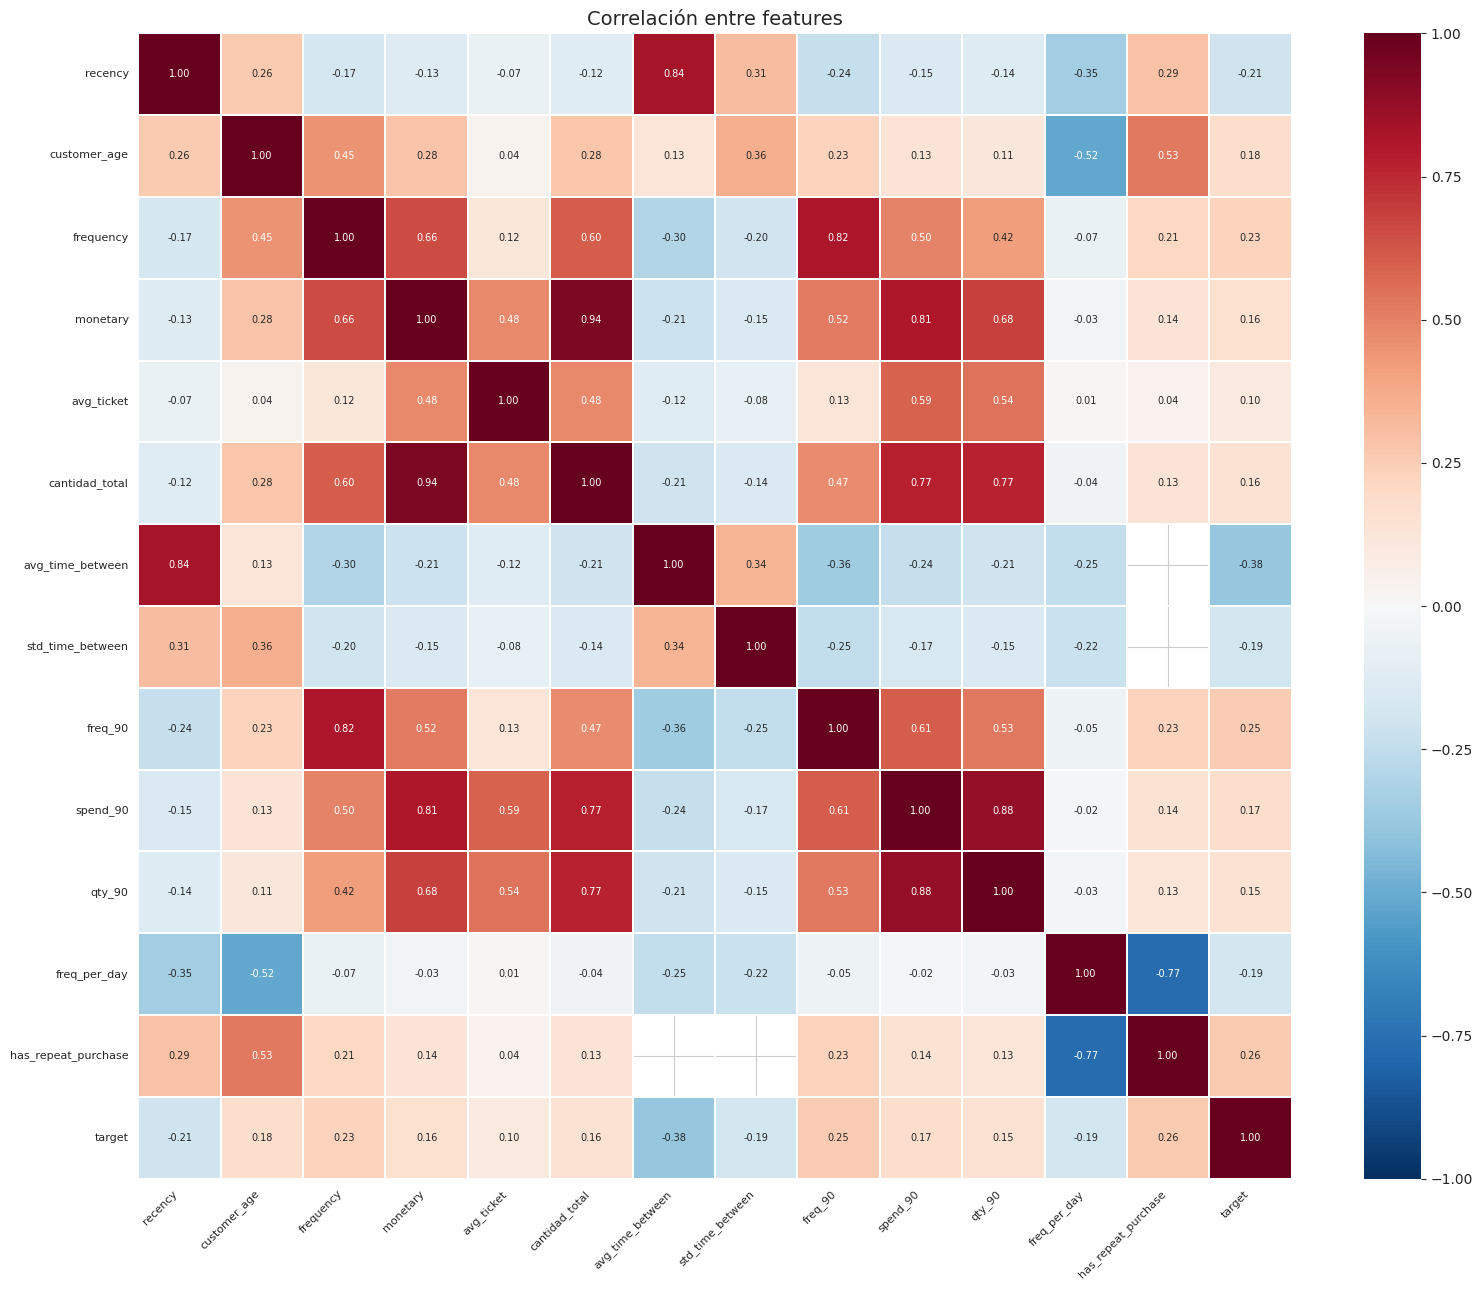

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionamos solo las numéricas + target
cols_plot = num_features + ["target"]
corr = df_features[cols_plot].corr()

# Mapa de correlaciones
plt.figure(figsize=(16, 13))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.3,
    annot_kws={"size": 7}
)
plt.title("Correlación entre features", fontsize=14)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()